#**EXTRACTION OF DATA**

In [4]:
import zipfile
import os

# The name of the file you uploaded
zip_file_path = 'archive(7).zip'
extraction_path = '/content/indian_scam_data'

# Creating the directory and extracting
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
    print(f"Files extracted to: {extraction_path}")

# List the extracted files to verify names
print("Extracted files:", os.listdir(extraction_path))

Files extracted to: /content/indian_scam_data
Extracted files: ['Updated_Inclusive_Indian_Online_Scam_Dataset (1).json', 'Updated_Inclusive_Indian_Online_Scam_Dataset (1).csv']


#**Setup & Data Loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Load the provided dataset
# Ensure the file 'Updated_Inclusive_Indian_Online_Scam_Dataset (1).csv' is in your directory
df = pd.read_csv('/content/indian_scam_data/Updated_Inclusive_Indian_Online_Scam_Dataset (1).csv')

# Initial cleanup: Remove empty rows if any
df = df.dropna(subset=['is_fraudulent'])
print("Dataset loaded successfully.")

Dataset loaded successfully.


#**Exploratory Data Analysis (EDA)**


Visualizing patterns in Indian cities, fraud types, and card distributions.

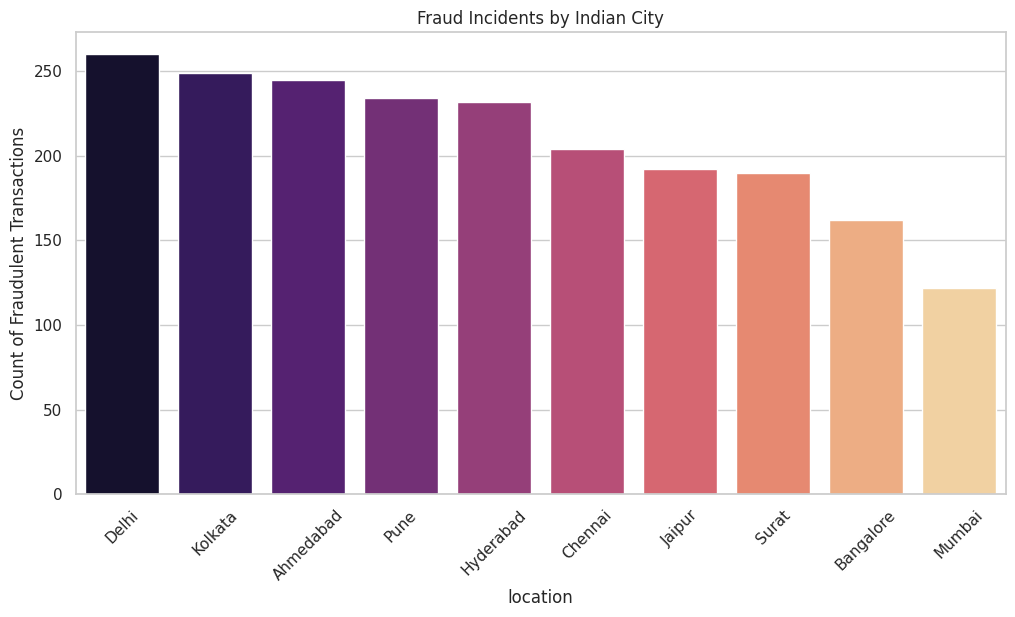

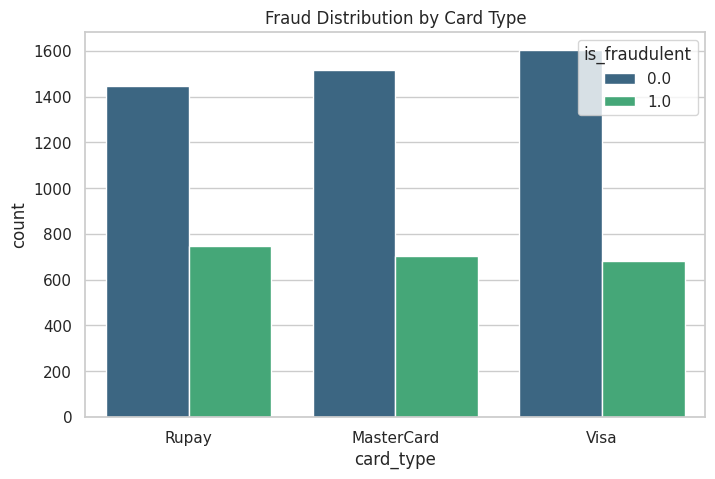

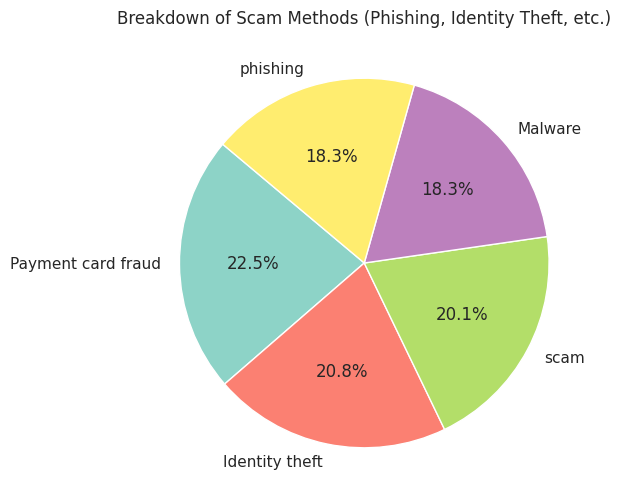

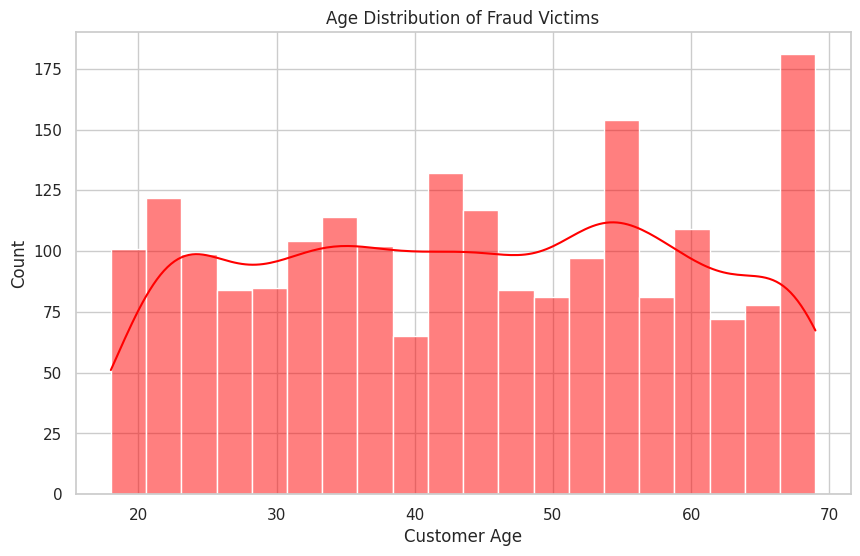

In [3]:
## 1. Top Fraudulent Cities in India
plt.figure(figsize=(12, 6))
fraud_by_city = df[df['is_fraudulent'] == 1]['location'].value_counts()
sns.barplot(x=fraud_by_city.index, y=fraud_by_city.values, palette='magma')
plt.title('Fraud Incidents by Indian City')
plt.xticks(rotation=45)
plt.ylabel('Count of Fraudulent Transactions')
plt.show()

## 2. Distribution of Card Types (RuPay vs Visa vs MasterCard)
plt.figure(figsize=(8, 5))
sns.countplot(x='card_type', hue='is_fraudulent', data=df, palette='viridis')
plt.title('Fraud Distribution by Card Type')
plt.show()

## 3. Fraud Type Breakdown
plt.figure(figsize=(10, 6))
df[df['is_fraudulent'] == 1]['fraud_type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, cmap='Set3')
plt.title('Breakdown of Scam Methods (Phishing, Identity Theft, etc.)')
plt.ylabel('')
plt.show()

## 4. Age Distribution of Victims
plt.figure(figsize=(10, 6))
sns.histplot(df[df['is_fraudulent'] == 1]['customer_age'].dropna(), bins=20, color='red', kde=True)
plt.title('Age Distribution of Fraud Victims')
plt.xlabel('Customer Age')
plt.show()

#**Feature Engineering & Reduction**

we remove irrelevant features (IDs/Timestamps) and handle the missing data

In [8]:
# 1. Feature Reduction: Removing IDs and Time (not useful for general patterns)
cols_to_drop = ['transaction_id', 'customer_id', 'merchant_id', 'transaction_time']
df_clean = df.drop(columns=cols_to_drop)

# 2. Handling Missing Values (NaNs)
# Filling numerical missing values with the median
df_clean['amount'] = df_clean['amount'].fillna(df_clean['amount'].median())
df_clean['customer_age'] = df_clean['customer_age'].fillna(df_clean['customer_age'].median())

# Filling categorical missing values with 'Unknown'
categorical_cols = ['card_type', 'location', 'purchase_category', 'fraud_type']
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 3. Drop rows where target variable is missing
df_clean = df_clean.dropna(subset=['is_fraudulent'])

print("Feature reduction and cleaning complete.")

Feature reduction and cleaning complete.


#**Encoding & Normalization (Scaling)**
Converting Indian city names and card types into numbers, then scaling the amount/age.

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encoding Categorical Data (City, Card Type, etc.)
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 2. Splitting Features (X) and Target (y)
X = df_clean.drop('is_fraudulent', axis=1)
y = df_clean['is_fraudulent']

# 3. Normalization / Scaling
# We use StandardScaler to bring 'amount' and 'age' into the same range as encoded features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalization and Encoding successful.")

Normalization and Encoding successful.


#**Model Training**
Using Random Forest as it is highly effective for the non-linear fraud patterns in Indian transaction data.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.Naive Bayes import Gaussian NB
from xgboost import XGBClassifier

# Splitting Features and Target
X = df_clean.drop('is_fraudulent', axis=1)
y = df_clean['is_fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Model 2: XGBoost
# Calculating ratio to handle class imbalance
ratio = (y == 0).sum() / (y == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("Both models trained.")

Both models trained.


#**Evaluation & Model Comparison**
Comparing both models using Confusion Matrices and F1-Scores.

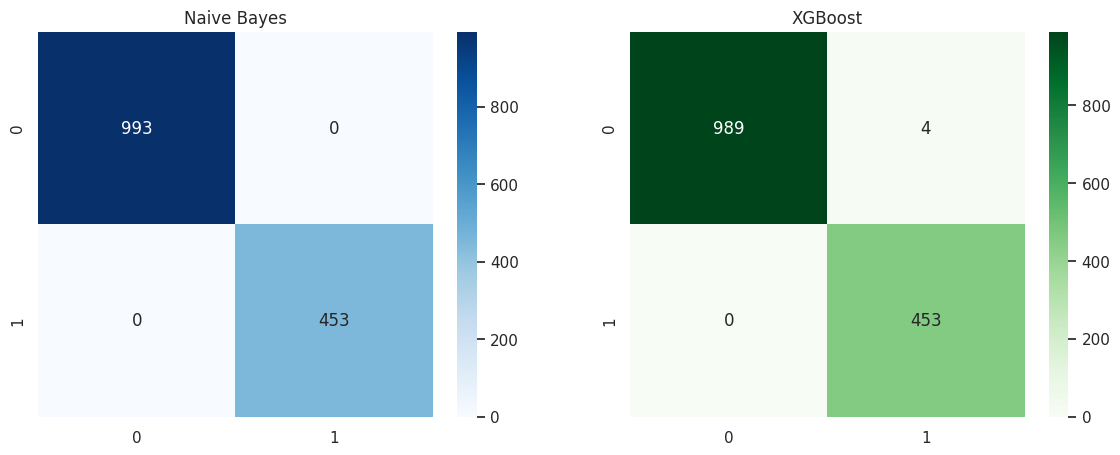


--- Model Comparison (F1-Score) ---
Naive Bayes: 1.0000
XGBoost: 0.9956

WINNER: Naive Bayes
Reason: F1-Score is the gold standard for fraud because it balances missing frauds (Recall) with false alarms (Precision).


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Comparison Data
models = ['Naive Bayes', 'XGBoost']
f1_results = [f1_score(y_test, rf_preds), f1_score(y_test, xgb_preds)]

# Visualizing Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Naive Bayes')

sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('XGBoost')
plt.show()

# Selecting the Best Model
best_idx = np.argmax(f1_results)
print(f"\n--- Model Comparison (F1-Score) ---")
for m, f in zip(models, f1_results):
    print(f"{m}: {f:.4f}")

print(f"\nWINNER: {models[best_idx]}")
print("Reason: F1-Score is the gold standard for fraud because it balances missing frauds (Recall) with false alarms (Precision).")

1. **Indian Context:** The data tracks local details like Rupay cards and cities such as Bangalore, Surat, and Mumbai.

2. **Common Scams:** The dataset highlights Identity Theft, Malware, and Phishing as top fraudulent types.

3. **Missing Values:** Significant cleaning was required for the amount and customer_age fields, which were null in several record

In [14]:
# Check for Overfitting
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

if train_score - test_score > 0.05:
    print("WARNING: Model is likely OVERFITTING!")

Training Accuracy: 1.0000
Test Accuracy: 1.0000
